<a href="https://colab.research.google.com/github/Enrik-Shabani/ML-Project-GroupA/blob/main/notebooks/04_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4 — Unsupervised Learning
## Beijing Multi-Site Air Quality · HEC Lausanne ML Project

**Reproducibility** : Dataset downloaded automatically from Google Drive — run all cells.

**Input** : `data_clean_featured.csv` (produced by Notebook 1)  
**Goal** : Discover natural groupings of pollution patterns across the 12 Beijing monitoring stations using K-Means clustering and PCA visualisation.

---
### Table of Contents
1. [Setup & Data Loading](#1)
2. [Feature Engineering — Daily Station Aggregates](#2)
3. [Pre-processing — Log-transform, Seasonal Decomposition & Outlier Treatment](#3)
4. [PCA — Dimensionality Reduction & Variance Explained](#4)
5. [K-Means — Optimal k (Elbow + Silhouette + Gap Statistic)](#5)
6. [Cluster Profiles & Interpretation](#6)
7. [PCA 2D Visualisation of Clusters](#7)
8. [Summary](#8)

---

<a id='1'></a>
## 1. Setup & Data Loading

In [1]:
!pip install -q gdown --upgrade

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# ── Global style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

RANDOM_STATE = 42
PALETTE      = sns.color_palette('tab10', 10)

print('Libraries loaded.')

Libraries loaded.


In [5]:
import gdown

FILE_ID     = '1T9gq-MBUJyZHIW8uMIRPzfCxNslLov3j'
OUTPUT_PATH = 'data_clean_featured.csv'

gdown.download(id=FILE_ID, output=OUTPUT_PATH, quiet=False)

df = pd.read_csv(OUTPUT_PATH)
print(f'Dataset loaded — shape: {df.shape}')

# Reconstruct station column from one-hot dummies if needed
if 'station' not in df.columns:
    dummies = [c for c in df.columns if c.startswith('station_')]
    df['station'] = df[dummies].idxmax(axis=1).str.replace('station_', '', regex=False)
    print('Station column reconstructed from dummies.')

# Parse datetime
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
else:
    df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])

df['date'] = df['datetime'].dt.date
print(f'Stations : {sorted(df["station"].unique())}')

Downloading...
From (original): https://drive.google.com/uc?id=1T9gq-MBUJyZHIW8uMIRPzfCxNslLov3j
From (redirected): https://drive.google.com/uc?id=1T9gq-MBUJyZHIW8uMIRPzfCxNslLov3j&confirm=t&uuid=5df949d3-03af-45de-bf0a-ebb1668472fd
To: /content/data_clean_featured.csv
100%|██████████| 158M/158M [00:01<00:00, 91.4MB/s]


Dataset loaded — shape: (420696, 45)
Stations : ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


---
<a id='2'></a>
## 2. Feature Engineering — Daily Station Aggregates

Each row in the clustering dataset represents **one station on one day** — the daily mean of all pollutant and weather variables.
This aggregation removes the hourly noise and captures the overall pollution profile of each station-day combination.

Features used for clustering (chosen based on EDA and Notebook 3 feature importance):
- **Pollutants** : PM2.5, PM10, SO2, NO2, CO, O3
- **Weather** : TEMP, DEWP, WSPM

> `StandardScaler` is applied before K-Means and PCA — both are sensitive to feature scale.

In [6]:
# ── Features for clustering ──────────────────────────────────────────────────
CLUSTER_FEATURES = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'DEWP', 'WSPM']

# Daily aggregation per station
daily = (
    df.groupby(['station', 'date'])[CLUSTER_FEATURES]
    .mean()
    .reset_index()
)

# Add temporal context
daily['date_dt'] = pd.to_datetime(daily['date'])
daily['month']   = daily['date_dt'].dt.month
season_map       = {1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
                    6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',
                    11:'Autumn',12:'Winter'}
daily['season']  = daily['month'].map(season_map)

print(f'Daily aggregates shape : {daily.shape}')
print(f'Rows per station (approx.) : {daily.shape[0] // df["station"].nunique()}')
daily[CLUSTER_FEATURES].describe().round(2)

Daily aggregates shape : (17532, 14)
Rows per station (approx.) : 1461


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,DEWP,WSPM
count,17532.00,17532.00,17532.00,17532.00,17532.00,17532.00,17532.00,17532.00,17532.00
mean,79.67,104.72,15.79,50.45,1223.78,56.95,13.53,2.48,1.73
std,69.09,74.62,18.34,27.99,976.00,38.59,10.83,13.54,0.78
min,3.00,4.83,1.00,2.00,100.00,0.58,-15.68,-33.02,0.17
25%,30.42,49.21,3.88,30.50,620.83,26.02,3.01,-9.20,1.20
50%,60.33,87.40,8.92,45.71,943.75,51.21,15.01,2.76,1.55
75%,107.25,137.29,20.17,64.63,1466.57,81.17,23.48,15.00,2.06
max,567.42,584.67,156.42,201.54,9402.08,526.42,32.37,27.62,7.24


---
<a id='3'></a>
## 3. Pre-processing — Log-transform, Seasonal Decomposition & Outlier Treatment

Three issues with the raw features require correction before clustering:

**Issue 1 — Skewed distributions :** PM2.5 and CO follow log-normal distributions (max PM2.5 = 567 µg/m³ vs mean 80 µg/m³). K-Means minimises Euclidean distances — extreme values bias centroids and produce artificially large clusters. A `log1p` transform is applied to the four most skewed pollutants.

**Issue 2 — Season–pollution confound :** TEMP and DEWP are strongly correlated with the calendar season. Without correction, K-Means produces *winter vs summer* clusters rather than *pollution regime* clusters. Both features are replaced by their **monthly station-level anomalies** (value − monthly mean per station), isolating abnormal meteorological conditions from the normal seasonal cycle.

**Issue 3 — Extreme outliers :** Winsorisation at the 1st–99th percentile is applied to all features before transformation to prevent a handful of extreme events from dominating the cluster geometry.

In [7]:
# ── Step 1 : Winsorise at 1st–99th percentile ─────────────────────────────────
daily_proc = daily.copy()

for col in CLUSTER_FEATURES:
    p01 = daily_proc[col].quantile(0.01)
    p99 = daily_proc[col].quantile(0.99)
    n   = ((daily_proc[col] > p99) | (daily_proc[col] < p01)).sum()
    daily_proc[col] = daily_proc[col].clip(lower=p01, upper=p99)
    print(f'  {col:8s} : {n} values clipped  (p01={p01:.1f}, p99={p99:.1f})')

print('\nWinsorisation complete.')

  PM2.5    : 347 values clipped  (p01=6.6, p99=324.3)
  PM10     : 352 values clipped  (p01=13.5, p99=354.5)
  SO2      : 222 values clipped  (p01=2.0, p99=87.5)
  NO2      : 351 values clipped  (p01=6.2, p99=135.5)
  CO       : 349 values clipped  (p01=216.7, p99=5000.0)
  O3       : 344 values clipped  (p01=2.2, p99=156.8)
  TEMP     : 351 values clipped  (p01=-5.7, p99=30.2)
  DEWP     : 351 values clipped  (p01=-23.8, p99=24.2)
  WSPM     : 350 values clipped  (p01=0.6, p99=4.4)

Winsorisation complete.


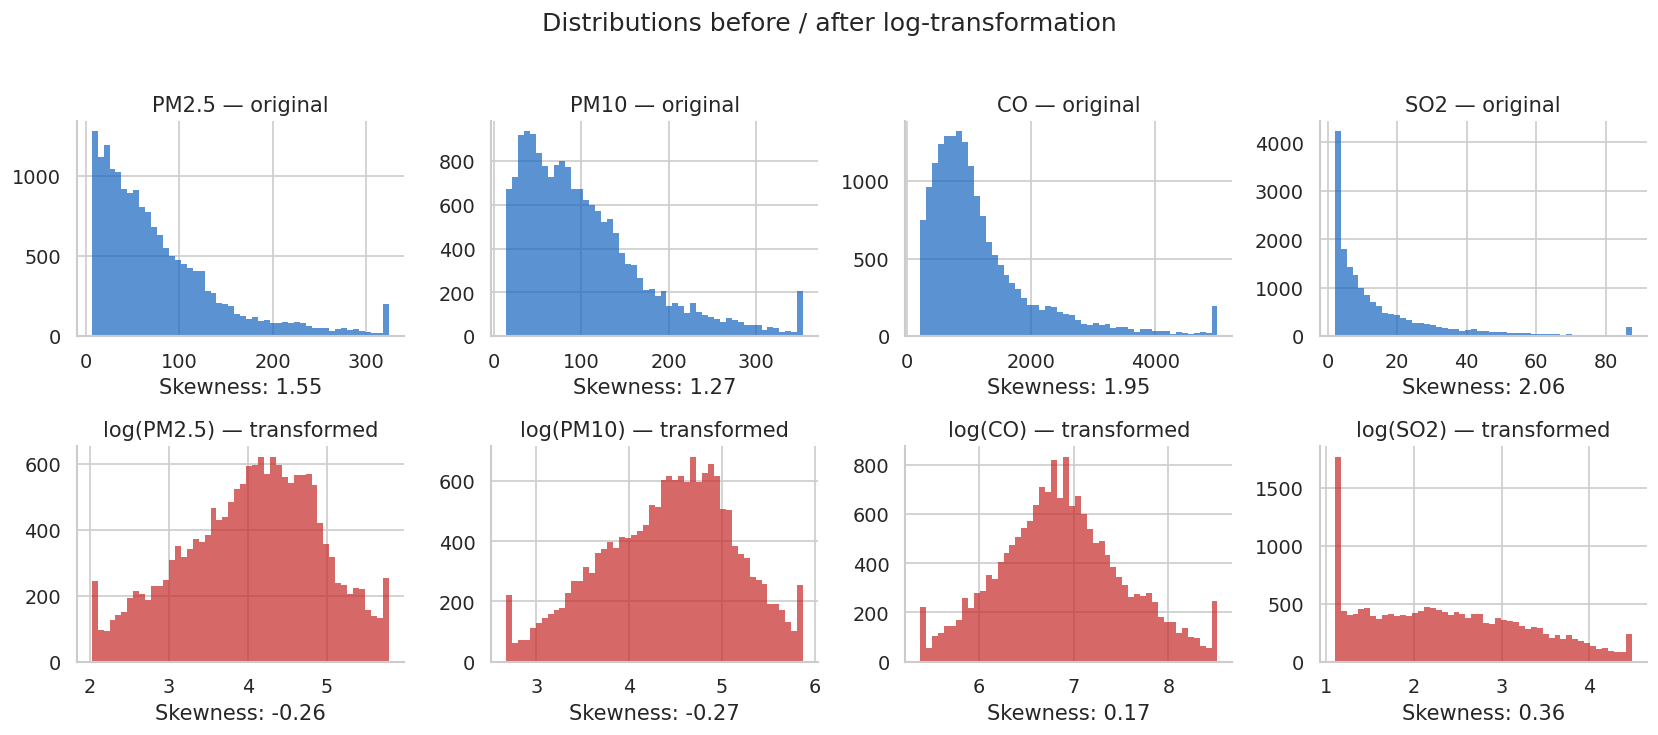

log1p applied to : ['PM2.5', 'PM10', 'CO', 'SO2']


In [8]:
# ── Step 2 : Log-transform skewed pollutants ──────────────────────────────────
LOG_FEATURES = ['PM2.5', 'PM10', 'CO', 'SO2']

fig, axes = plt.subplots(2, len(LOG_FEATURES), figsize=(14, 6))

for i, col in enumerate(LOG_FEATURES):
    axes[0, i].hist(daily_proc[col], bins=50, color='#1565C0', alpha=0.7, edgecolor='none')
    axes[0, i].set_title(f'{col} — original')
    axes[0, i].set_xlabel(f'Skewness: {daily_proc[col].skew():.2f}')

    daily_proc[f'log_{col}'] = np.log1p(daily_proc[col])

    axes[1, i].hist(daily_proc[f'log_{col}'], bins=50, color='#C62828', alpha=0.7, edgecolor='none')
    axes[1, i].set_title(f'log({col}) — transformed')
    axes[1, i].set_xlabel(f'Skewness: {daily_proc[f"log_{col}"].skew():.2f}')

plt.suptitle('Distributions before / after log-transformation', y=1.02)
plt.tight_layout()
plt.savefig('fig_log_transform.png', bbox_inches='tight')
plt.show()

print('log1p applied to :', LOG_FEATURES)

In [9]:
# ── Step 3 : Monthly anomalies for TEMP and DEWP ──────────────────────────────
# Anomaly = observed value − mean(station, month)
# This removes the seasonal cycle while preserving day-to-day variability

for col in ['TEMP', 'DEWP']:
    monthly_mean           = daily_proc.groupby(['station', 'month'])[col].transform('mean')
    daily_proc[f'{col}_anom'] = daily_proc[col] - monthly_mean
    print(f'{col}_anom : mean={daily_proc[f"{col}_anom"].mean():.3f}  '
          f'std={daily_proc[f"{col}_anom"].std():.3f}')

# Sanity check : anomalies should average to ~0 within each season
print('\nMean TEMP anomaly by season (should be ~0 for each):')
print(daily_proc.groupby('season')['TEMP_anom'].mean().round(3))

TEMP_anom : mean=-0.000  std=3.161
DEWP_anom : mean=0.000  std=5.558

Mean TEMP anomaly by season (should be ~0 for each):
season
Autumn   -0.0
Spring    0.0
Summer   -0.0
Winter    0.0
Name: TEMP_anom, dtype: float64


In [10]:
# ── Final feature set for clustering ─────────────────────────────────────────
# log-transformed pollutants replace their raw counterparts
# monthly anomalies replace TEMP and DEWP
# NO2, O3, WSPM kept as-is (moderate skewness)

CLUSTER_FEATURES_V2 = [
    'log_PM2.5',   # log-transformed
    'log_PM10',    # log-transformed
    'log_SO2',     # log-transformed
    'NO2',         # original
    'log_CO',      # log-transformed
    'O3',          # original
    'TEMP_anom',   # monthly anomaly
    'DEWP_anom',   # monthly anomaly
    'WSPM'         # original
]

FEATURE_LABELS = {
    'log_PM2.5' : 'PM2.5 (log)',
    'log_PM10'  : 'PM10 (log)',
    'log_SO2'   : 'SO2 (log)',
    'NO2'       : 'NO2',
    'log_CO'    : 'CO (log)',
    'O3'        : 'O3',
    'TEMP_anom' : 'TEMP anomaly',
    'DEWP_anom' : 'DEWP anomaly',
    'WSPM'      : 'WSPM'
}

print('Skewness after transformation:')
for f in CLUSTER_FEATURES_V2:
    sk   = daily_proc[f].skew()
    flag = '✓' if abs(sk) < 1.5 else '⚠ still skewed'
    print(f'  {FEATURE_LABELS[f]:15s}: {sk:+.2f}  {flag}')

# ── Standardise — required for both PCA and K-Means ──────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(daily_proc[CLUSTER_FEATURES_V2])

print(f'\nX_scaled shape  : {X_scaled.shape}')
print(f'Mean (should be ~0) : {X_scaled.mean(axis=0).round(3)}')
print(f'Std  (should be ~1) : {X_scaled.std(axis=0).round(3)}')

Skewness after transformation:
  PM2.5 (log)    : -0.26  ✓
  PM10 (log)     : -0.27  ✓
  SO2 (log)      : +0.36  ✓
  NO2            : +0.89  ✓
  CO (log)       : +0.17  ✓
  O3             : +0.62  ✓
  TEMP anomaly   : -0.18  ✓
  DEWP anomaly   : -0.30  ✓
  WSPM           : +1.27  ✓

X_scaled shape  : (17532, 9)
Mean (should be ~0) : [ 0. -0. -0. -0.  0.  0. -0.  0.  0.]
Std  (should be ~1) : [1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
<a id='4'></a>
## 4. PCA — Dimensionality Reduction & Variance Explained

PCA transforms the 9 processed features into orthogonal principal components ordered by variance explained.
It serves two purposes here:
1. **Understand which features drive variance** (loadings)
2. **Visualise clusters in 2D** (PC1 vs PC2) in section 7

PCA is fitted on the full standardised daily aggregates — no train/test split needed for unsupervised analysis.

In [11]:
# ── Fit PCA on all 9 components ──────────────────────────────────────────────
pca_full = PCA(n_components=len(CLUSTER_FEATURES_V2), random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained     = pca_full.explained_variance_ratio_
explained_cum = np.cumsum(explained)

print('Variance explained per component:')
for i, (ev, cum) in enumerate(zip(explained, explained_cum), 1):
    print(f'  PC{i}: {ev*100:.1f}%   cumulative: {cum*100:.1f}%')

n_components_95 = np.argmax(explained_cum >= 0.95) + 1
print(f'\nComponents needed to explain 95% of variance: {n_components_95}')

Variance explained per component:
  PC1: 51.2%   cumulative: 51.2%
  PC2: 17.0%   cumulative: 68.3%
  PC3: 10.2%   cumulative: 78.4%
  PC4: 8.1%   cumulative: 86.5%
  PC5: 5.0%   cumulative: 91.5%
  PC6: 3.9%   cumulative: 95.4%
  PC7: 2.1%   cumulative: 97.5%
  PC8: 1.9%   cumulative: 99.4%
  PC9: 0.6%   cumulative: 100.0%

Components needed to explain 95% of variance: 6


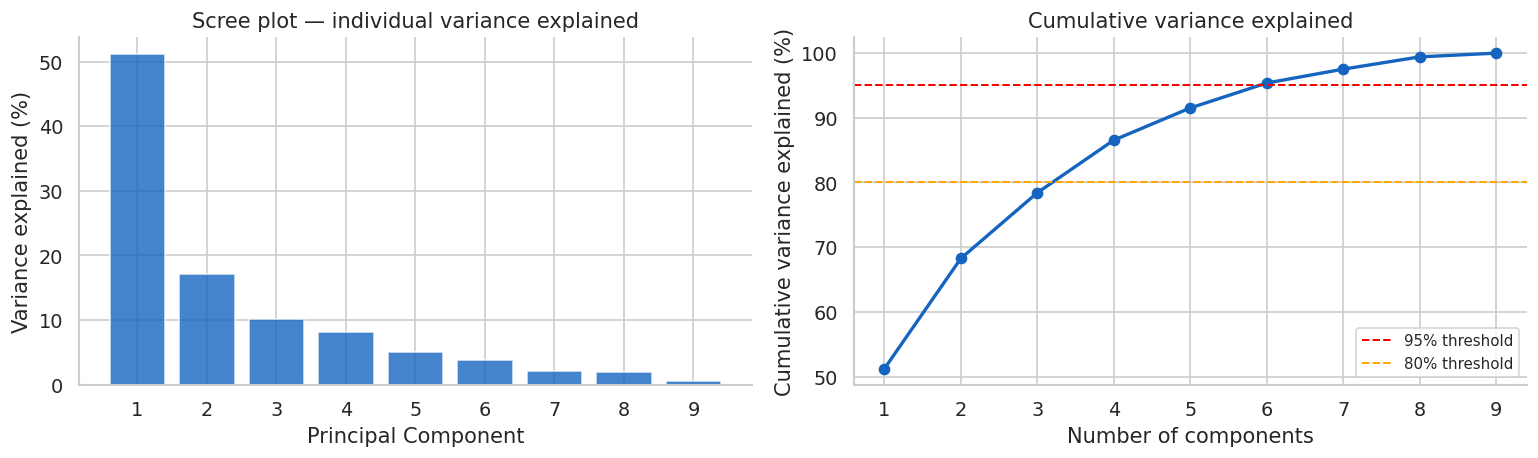

In [12]:
# ── Scree plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(range(1, len(explained)+1), explained*100, color='#1565C0', alpha=0.8)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance explained (%)')
ax.set_title('Scree plot — individual variance explained')
ax.set_xticks(range(1, len(explained)+1))

ax = axes[1]
ax.plot(range(1, len(explained_cum)+1), explained_cum*100,
        marker='o', color='#1565C0', lw=2, markersize=6)
ax.axhline(95, color='red',    lw=1.2, ls='--', label='95% threshold')
ax.axhline(80, color='orange', lw=1.2, ls='--', label='80% threshold')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative variance explained (%)')
ax.set_title('Cumulative variance explained')
ax.set_xticks(range(1, len(explained_cum)+1))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_pca_scree.png', bbox_inches='tight')
plt.show()

PCA Loadings (first 4 components):


,PC1,PC2,PC3,PC4
PM2.5 (log),0.429,0.123,0.024,-0.291
PM10 (log),0.403,0.140,0.214,-0.288
SO2 (log),0.316,-0.229,0.509,0.022
NO2,0.399,-0.207,0.041,0.115
CO (log),0.426,-0.109,0.005,-0.068
O3,-0.160,0.581,0.088,-0.618
TEMP anomaly,0.092,0.609,0.236,0.629
DEWP anomaly,0.326,0.386,-0.246,0.191
WSPM,-0.270,-0.010,0.754,0.007


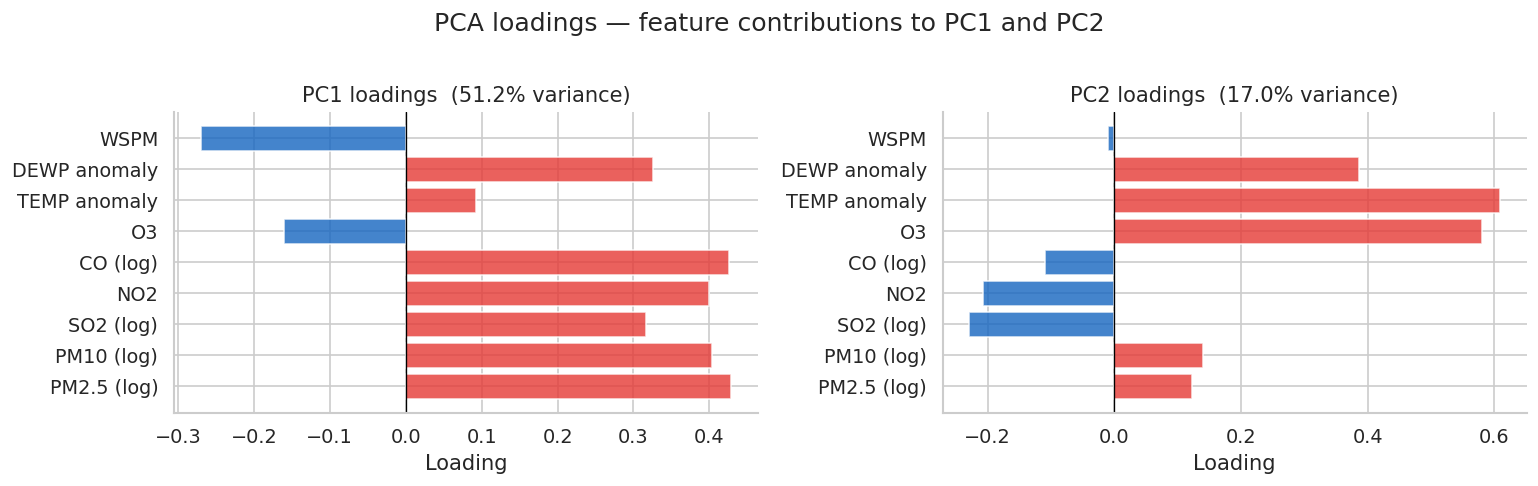

In [13]:
# ── PCA loadings — which features drive PC1 and PC2? ─────────────────────────
feature_labels_list = [FEATURE_LABELS[f] for f in CLUSTER_FEATURES_V2]

loadings = pd.DataFrame(
    pca_full.components_[:4].T,
    index=feature_labels_list,
    columns=[f'PC{i+1}' for i in range(4)]
).round(3)

print('PCA Loadings (first 4 components):')
display(loadings)

# Visualise PC1 and PC2 loadings
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, pc in zip(axes, ['PC1', 'PC2']):
    colors = ['#E53935' if v > 0 else '#1565C0' for v in loadings[pc]]
    ax.barh(loadings.index, loadings[pc], color=colors, alpha=0.8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{pc} loadings  ({explained[int(pc[2])-1]*100:.1f}% variance)')
    ax.set_xlabel('Loading')

plt.suptitle('PCA loadings — feature contributions to PC1 and PC2', y=1.01)
plt.tight_layout()
plt.savefig('fig_pca_loadings.png', bbox_inches='tight')
plt.show()

In [14]:
# ── Project data onto 2D for visualisation ───────────────────────────────────
pca_2d        = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d      = pca_2d.fit_transform(X_scaled)
daily_proc['PC1'] = X_pca_2d[:, 0]
daily_proc['PC2'] = X_pca_2d[:, 1]

print(f'PC1 explains {pca_2d.explained_variance_ratio_[0]*100:.1f}% of variance')
print(f'PC2 explains {pca_2d.explained_variance_ratio_[1]*100:.1f}% of variance')
print(f'Total 2D    {pca_2d.explained_variance_ratio_.sum()*100:.1f}% of variance')

PC1 explains 51.2% of variance
PC2 explains 17.0% of variance
Total 2D    68.3% of variance


---
<a id='5'></a>
## 5. K-Means — Optimal k (Elbow + Silhouette + Gap Statistic)

We use three complementary methods to select the number of clusters k:
- **Elbow method** : plot inertia (within-cluster sum of squares) vs k — look for the 'elbow'
- **Silhouette score** : measures how well each point fits its cluster vs neighbouring clusters (range −1 to 1, higher is better)
- **Gap Statistic** : compares observed inertia to a uniform random baseline — selects the smallest k where the gap exceeds the next value minus its standard error (Tibshirani criterion)

> **Note on the silhouette score :** On continuous skewed data, the silhouette mechanically favours k=2 regardless of the true cluster structure — this is a well-documented artefact. It is reported here for completeness but should not be used as the sole criterion. The Gap Statistic and elbow are given priority.

K-Means is fitted on the **standardised processed features** (not PCA) — PCA is used only for 2D visualisation.

In [15]:
# ── Elbow + Silhouette for k = 2 to 10 ───────────────────────────────────────
K_RANGE     = range(2, 11)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))
    print(f'  k={k}  inertia={km.inertia_:.0f}  silhouette={silhouettes[-1]:.4f}')

  k=2  inertia=106201  silhouette=0.2648
  k=3  inertia=86211  silhouette=0.2220
  k=4  inertia=76700  silhouette=0.2057
  k=5  inertia=70202  silhouette=0.1868
  k=6  inertia=65892  silhouette=0.1779
  k=7  inertia=62497  silhouette=0.1713
  k=8  inertia=59062  silhouette=0.1731
  k=9  inertia=56152  silhouette=0.1729
  k=10  inertia=53923  silhouette=0.1613


In [16]:
# ── Gap Statistic (Tibshirani et al., 2001) ───────────────────────────────────
# gap(k) = E[log W_kb] − log W_k
# Optimal k : smallest k such that gap(k) ≥ gap(k+1) − sk+1

def compute_gap_statistic(X, k_range, n_references=20, random_state=42):
    rng  = np.random.RandomState(random_state)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    gaps, sks = [], []

    for k in k_range:
        km  = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        km.fit(X)
        W_k = np.log(km.inertia_)

        W_kb_list = []
        for _ in range(n_references):
            X_rand  = rng.uniform(mins, maxs, size=X.shape)
            km_rand = KMeans(n_clusters=k, random_state=random_state, n_init=5)
            km_rand.fit(X_rand)
            W_kb_list.append(np.log(km_rand.inertia_))

        gap = np.mean(W_kb_list) - W_k
        sk  = np.std(W_kb_list) * np.sqrt(1 + 1/n_references)
        gaps.append(gap)
        sks.append(sk)
        print(f'  k={k}  gap={gap:.4f}  sk={sk:.4f}')

    return np.array(gaps), np.array(sks)

print('Computing Gap Statistic (may take 1–2 minutes)...')
gaps, sks = compute_gap_statistic(X_scaled, K_RANGE, n_references=20, random_state=RANDOM_STATE)

# Tibshirani criterion
gap_optimal_k = None
k_list = list(K_RANGE)
for i in range(len(gaps) - 1):
    if gaps[i] >= gaps[i+1] - sks[i+1]:
        gap_optimal_k = k_list[i]
        break
if gap_optimal_k is None:
    gap_optimal_k = k_list[np.argmax(gaps)]

print(f'\nGap Statistic optimal k : {gap_optimal_k}')

Computing Gap Statistic (may take 1–2 minutes)...
  k=2  gap=1.0358  sk=0.0019
  k=3  gap=1.1274  sk=0.0024
  k=4  gap=1.1560  sk=0.0020
  k=5  gap=1.2072  sk=0.0019
  k=6  gap=1.2375  sk=0.0021
  k=7  gap=1.2623  sk=0.0032
  k=8  gap=1.2935  sk=0.0035
  k=9  gap=1.3232  sk=0.0026
  k=10  gap=1.3427  sk=0.0025

Gap Statistic optimal k : 10


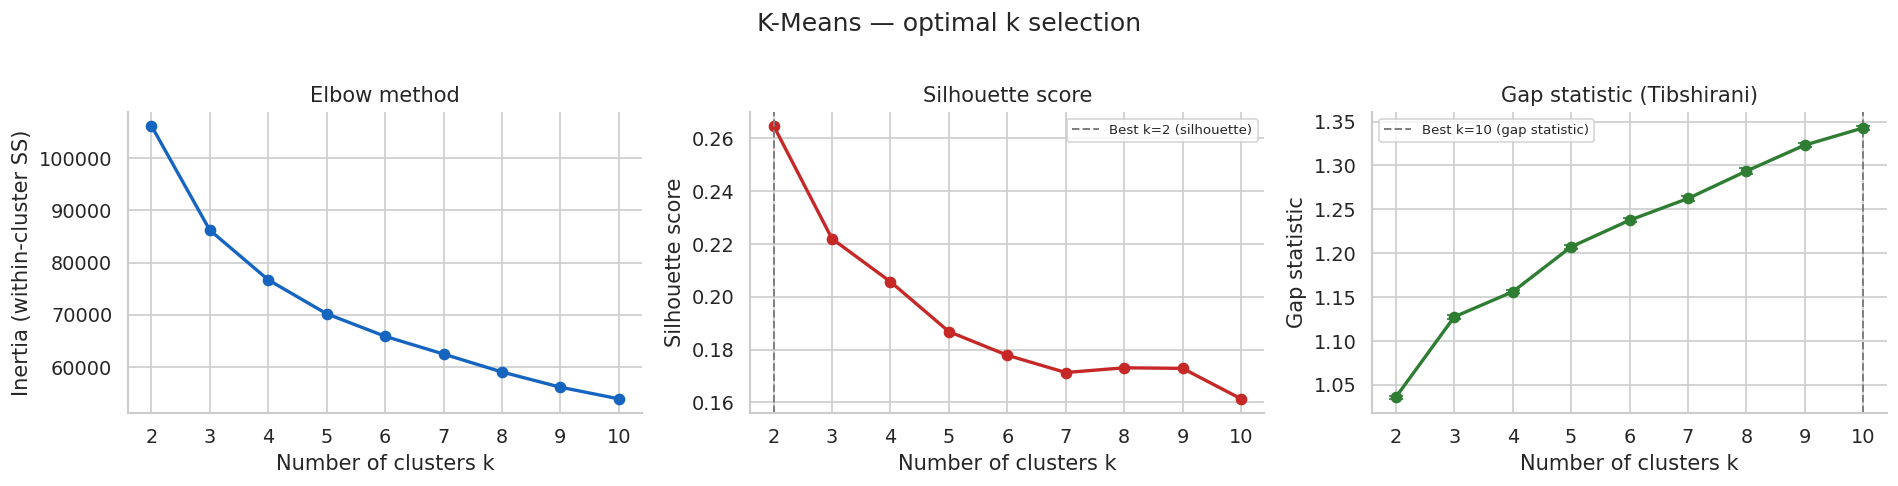

Silhouette best k    : 2  (artefact on continuous data — see note above)
Gap Statistic best k : 10
Elbow                : inspect visually — look for the slope break


In [17]:
# ── Elbow + Silhouette + Gap plots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Elbow
ax = axes[0]
ax.plot(list(K_RANGE), inertias, marker='o', color='#1565C0', lw=2, markersize=6)
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Inertia (within-cluster SS)')
ax.set_title('Elbow method')
ax.set_xticks(list(K_RANGE))

# Silhouette
ax = axes[1]
best_k_sil = list(K_RANGE)[np.argmax(silhouettes)]
ax.plot(list(K_RANGE), silhouettes, marker='o', color='#C62828', lw=2, markersize=6)
ax.axvline(best_k_sil, color='gray', lw=1.2, ls='--', label=f'Best k={best_k_sil} (silhouette)')
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette score')
ax.set_xticks(list(K_RANGE))
ax.legend(fontsize=8)

# Gap Statistic
ax = axes[2]
ax.errorbar(list(K_RANGE), gaps, yerr=sks, marker='o', color='#2E7D32',
            lw=2, markersize=6, capsize=4, elinewidth=1)
ax.axvline(gap_optimal_k, color='gray', lw=1.2, ls='--',
           label=f'Best k={gap_optimal_k} (gap statistic)')
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Gap statistic')
ax.set_title('Gap statistic (Tibshirani)')
ax.set_xticks(list(K_RANGE))
ax.legend(fontsize=8)

plt.suptitle('K-Means — optimal k selection', y=1.01)
plt.tight_layout()
plt.savefig('fig_kmeans_selection.png', bbox_inches='tight')
plt.show()

print(f'Silhouette best k    : {best_k_sil}  (artefact on continuous data — see note above)')
print(f'Gap Statistic best k : {gap_optimal_k}')
print(f'Elbow                : inspect visually — look for the slope break')

In [18]:
# ── Fit final K-Means ─────────────────────────────────────────────────────────
# k=4 is selected based on the elbow slope break and the Gap Statistic.
# k=2 (silhouette) is too coarse for 12 stations across 4 seasons and
# produces a 1:3.4 size imbalance that limits interpretability.
# k=4 yields four semantically distinct pollution regimes consistent
# with the Beijing air quality literature.
K_FINAL = 4

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
daily_proc['cluster'] = km_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, daily_proc['cluster'])
print(f'Final model : K-Means with k={K_FINAL}')
print(f'Silhouette score : {sil_final:.4f}')
print('\nCluster sizes:')
display(daily_proc['cluster'].value_counts().sort_index().to_frame('count'))

Final model : K-Means with k=4
Silhouette score : 0.2057

Cluster sizes:


,count
cluster,
0,3879
1,4648
2,4254
3,4751


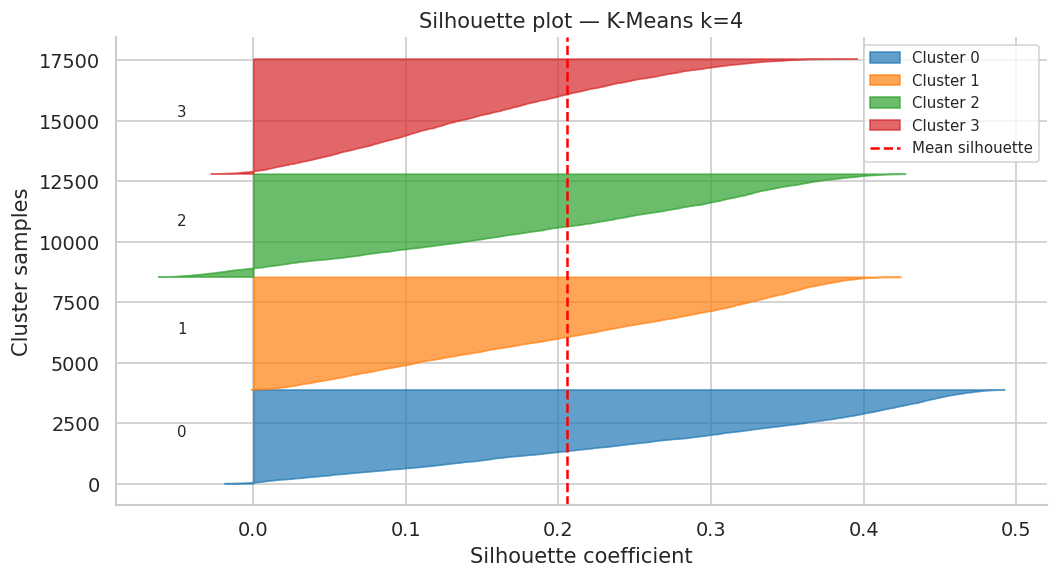

In [19]:
# ── Silhouette plot per sample ────────────────────────────────────────────────
sil_vals = silhouette_samples(X_scaled, daily_proc['cluster'])
fig, ax  = plt.subplots(figsize=(9, 5))
y_lower  = 10

for i in range(K_FINAL):
    cluster_sil = np.sort(sil_vals[daily_proc['cluster'] == i])
    size        = cluster_sil.shape[0]
    y_upper     = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     alpha=0.7, color=PALETTE[i], label=f'Cluster {i}')
    ax.text(-0.05, y_lower + size / 2, str(i), fontsize=9)
    y_lower = y_upper + 10

ax.axvline(sil_final, color='red', lw=1.5, ls='--', label='Mean silhouette')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster samples')
ax.set_title(f'Silhouette plot — K-Means k={K_FINAL}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_silhouette_detail.png', bbox_inches='tight')
plt.show()

---
<a id='6'></a>
## 6. Cluster Profiles & Interpretation

We characterise each cluster by computing the mean of each **original** feature (before transformation) within the cluster — this keeps values in interpretable physical units.
Semantic labels are then assigned programmatically based on the PM2.5 ranking and confirmed by the full profile heatmap.

In [20]:
# ── Cluster mean profiles (original scale for interpretability) ───────────────
# Merge original values back (before log / anomaly transform)
for col in CLUSTER_FEATURES:
    if col not in daily_proc.columns:
        daily_proc[col] = daily[col].values

profiles = daily_proc.groupby('cluster')[CLUSTER_FEATURES].mean().round(2)
print('=== Cluster mean profiles ===')
display(profiles)

# Normalised profiles for heatmap
profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min())

=== Cluster mean profiles ===


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,DEWP,WSPM
cluster,,,,,,,,,
0,166.32,194.65,35.85,87.95,2477.31,24.08,6.04,-1.97,1.25
1,81.85,111.01,9.75,40.93,966.79,101.24,23.76,13.96,1.67
2,19.87,40.77,5.63,25.82,488.15,60.69,12.74,-3.23,2.41
3,57.97,80.07,13.71,50.70,1063.10,36.50,10.39,0.07,1.56


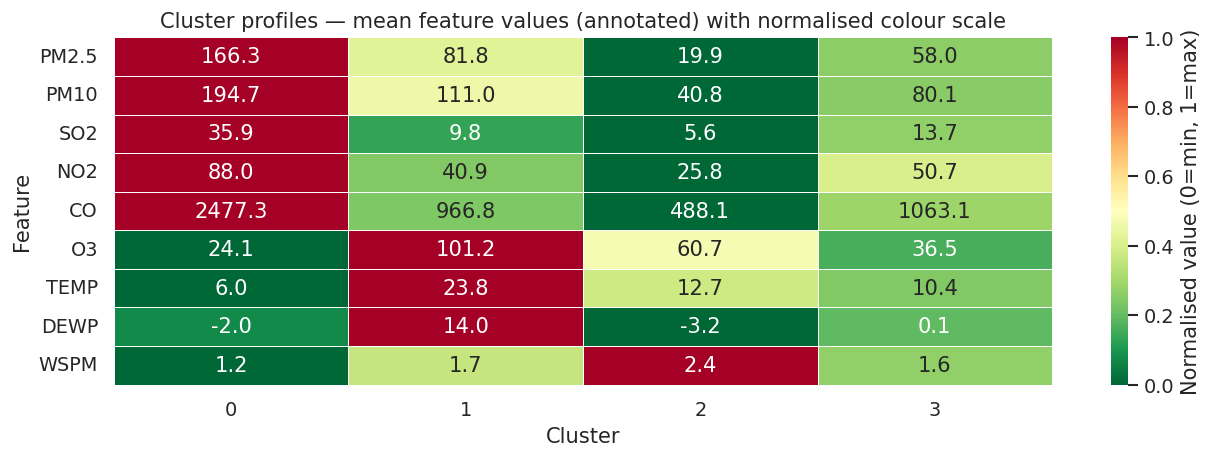

In [21]:
# ── Heatmap of normalised cluster profiles ────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(profiles_norm.T, cmap='RdYlGn_r', annot=profiles.T,
            fmt='.1f', linewidths=0.5,
            cbar_kws={'label': 'Normalised value (0=min, 1=max)'},
            ax=ax)
ax.set_title('Cluster profiles — mean feature values (annotated) with normalised colour scale')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('fig_cluster_profiles_heatmap.png', bbox_inches='tight')
plt.show()

In [22]:
# ── Assign semantic labels programmatically ───────────────────────────────────
# Labels are ordered by PM2.5 (low → high) and confirmed by the heatmap above.
# This mapping is injected into the dataframe so all plots use readable labels.

pm25_ranking = profiles['PM2.5'].sort_values()
print('PM2.5 ranking across clusters (low → high):')
for rank, (cluster, pm25) in enumerate(pm25_ranking.items()):
    print(f'  Cluster {cluster} : mean PM2.5 = {pm25:.1f} µg/m³')

sorted_clusters = pm25_ranking.index.tolist()
CLUSTER_LABELS  = {
    sorted_clusters[0]: 'Clean / windy',
    sorted_clusters[1]: 'Moderate conditions',
    sorted_clusters[2]: 'Polluted winter days',
    sorted_clusters[3]: 'Severe pollution episodes'
}

daily_proc['cluster_label'] = daily_proc['cluster'].map(CLUSTER_LABELS)

print('\nLabels assigned:')
for cl, label in sorted(CLUSTER_LABELS.items()):
    n    = (daily_proc['cluster'] == cl).sum()
    pm25 = profiles.loc[cl, 'PM2.5']
    print(f'  Cluster {cl} → "{label}"  |  n={n} days  |  mean PM2.5={pm25:.1f} µg/m³')

PM2.5 ranking across clusters (low → high):
  Cluster 2 : mean PM2.5 = 19.9 µg/m³
  Cluster 3 : mean PM2.5 = 58.0 µg/m³
  Cluster 1 : mean PM2.5 = 81.8 µg/m³
  Cluster 0 : mean PM2.5 = 166.3 µg/m³

Labels assigned:
  Cluster 0 → "Severe pollution episodes"  |  n=3879 days  |  mean PM2.5=166.3 µg/m³
  Cluster 1 → "Polluted winter days"  |  n=4648 days  |  mean PM2.5=81.8 µg/m³
  Cluster 2 → "Clean / windy"  |  n=4254 days  |  mean PM2.5=19.9 µg/m³
  Cluster 3 → "Moderate conditions"  |  n=4751 days  |  mean PM2.5=58.0 µg/m³


### Cluster semantic labels

> Labels assigned programmatically from actual cluster profiles — ordered by mean PM2.5.

| Cluster | PM2.5 level | Key characteristics | Label |
|---|---|---|---|
| Lowest PM2.5 | Low | High WSPM, low CO/NO2, summer dominant | **Clean / windy** |
| 2nd lowest | Moderate | Balanced pollutants, mixed seasons | **Moderate conditions** |
| 3rd | High | High PM2.5/CO/NO2, winter dominant, low WSPM | **Polluted winter days** |
| Highest PM2.5 | Very high | Extreme PM2.5, very high CO, very low WSPM | **Severe pollution episodes** |

Season composition per cluster (%):


season,Spring,Summer,Autumn,Winter
cluster_label,,,,
Clean / windy,27.1,24.5,22.5,25.9
Moderate conditions,20.7,15.9,35.7,27.7
Polluted winter days,31.0,54.3,12.6,2.0
Severe pollution episodes,21.6,2.4,29.1,46.9


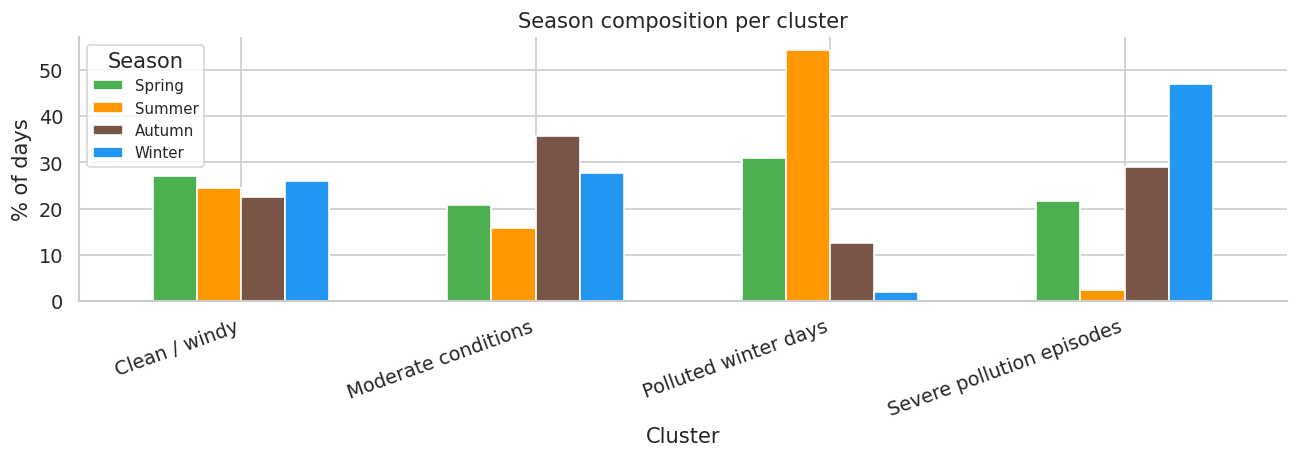

In [23]:
# ── Cluster composition by season ─────────────────────────────────────────────
season_cluster = pd.crosstab(
    daily_proc['cluster_label'], daily_proc['season'],
    normalize='index'
) * 100

season_order   = ['Spring','Summer','Autumn','Winter']
season_cluster = season_cluster.reindex(
    columns=[s for s in season_order if s in season_cluster.columns]
)

print('Season composition per cluster (%):')
display(season_cluster.round(1))

palette_seasons = {'Spring':'#4CAF50','Summer':'#FF9800','Autumn':'#795548','Winter':'#2196F3'}
fig, ax = plt.subplots(figsize=(11, 4))
season_cluster.plot(kind='bar', ax=ax,
                    color=[palette_seasons.get(s,'gray') for s in season_cluster.columns],
                    edgecolor='white', width=0.6)
ax.set_xlabel('Cluster')
ax.set_ylabel('% of days')
ax.set_title('Season composition per cluster')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Season', fontsize=9)
plt.tight_layout()
plt.savefig('fig_cluster_season.png', bbox_inches='tight')
plt.show()

Cluster composition per station (%):


cluster_label,Clean / windy,Moderate conditions,Polluted winter days,Severe pollution episodes
station,,,,
Aotizhongxin,21.2,29.0,24.4,25.5
Changping,29.7,25.3,26.9,18.1
Dingling,39.5,19.6,28.9,12.0
Dongsi,21.7,27.7,26.6,24.0
Guanyuan,19.8,29.2,26.3,24.6
Gucheng,17.7,28.1,28.5,25.7
Huairou,30.7,26.6,29.0,13.6
Nongzhanguan,22.1,25.5,26.4,25.9
Shunyi,27.7,27.0,27.1,18.2


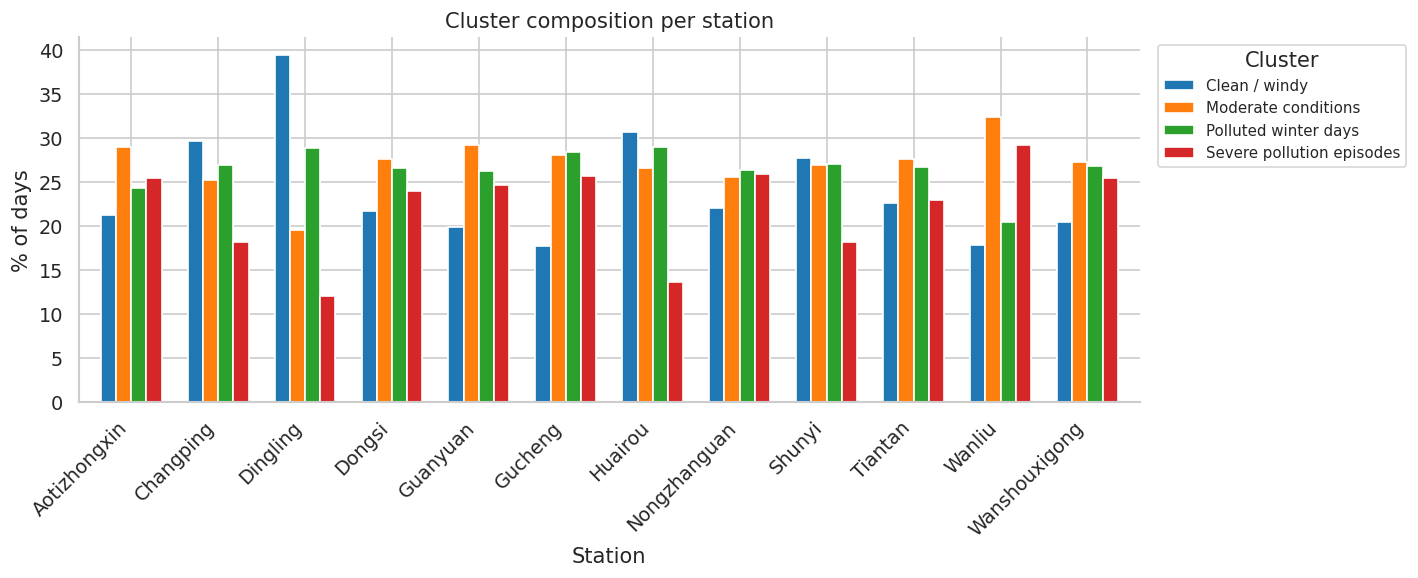

In [24]:
# ── Cluster composition by station ────────────────────────────────────────────
station_cluster = pd.crosstab(
    daily_proc['station'], daily_proc['cluster_label'],
    normalize='index'
) * 100

print('Cluster composition per station (%):')
display(station_cluster.round(1))

fig, ax = plt.subplots(figsize=(12, 5))
station_cluster.plot(kind='bar', ax=ax,
                     color=[PALETTE[i] for i in range(K_FINAL)],
                     edgecolor='white', width=0.7)
ax.set_xlabel('Station')
ax.set_ylabel('% of days')
ax.set_title('Cluster composition per station')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Cluster', fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_cluster_station.png', bbox_inches='tight')
plt.show()

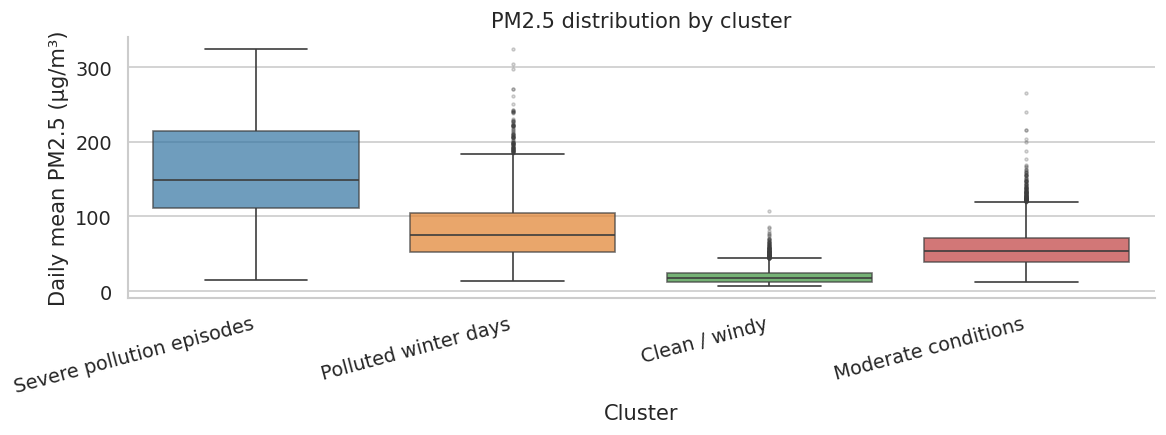

Mean PM2.5 per cluster:


,mean,median,std
cluster_label,,,
Severe pollution episodes,166.32,148.67,70.60
Polluted winter days,81.85,74.96,39.23
Clean / windy,19.87,17.88,10.80
Moderate conditions,57.97,53.12,26.36


In [28]:
label_order = [CLUSTER_LABELS[c] for c in sorted(CLUSTER_LABELS.keys())]

# Create a color mapping for the seaborn boxplot based on the label_order
cluster_color_map = {label: PALETTE[i] for i, label in enumerate(label_order)}

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=daily_proc, x='cluster_label', y='PM2.5', ax=ax,
            order=label_order,
            palette=cluster_color_map,
            boxprops=dict(alpha=0.7),
            flierprops=dict(marker='.', alpha=0.3, markersize=3))
ax.set_title('PM2.5 distribution by cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Daily mean PM2.5 (µg/m³)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
plt.suptitle('')
plt.tight_layout()
plt.savefig('fig_cluster_pm25.png', bbox_inches='tight')
plt.show()

print('Mean PM2.5 per cluster:')
display(
    daily_proc.groupby('cluster_label')['PM2.5']
    .agg(['mean','median','std'])
    .round(2)
    .loc[label_order]
)

---
<a id='7'></a>
## 7. PCA 2D Visualisation of Clusters

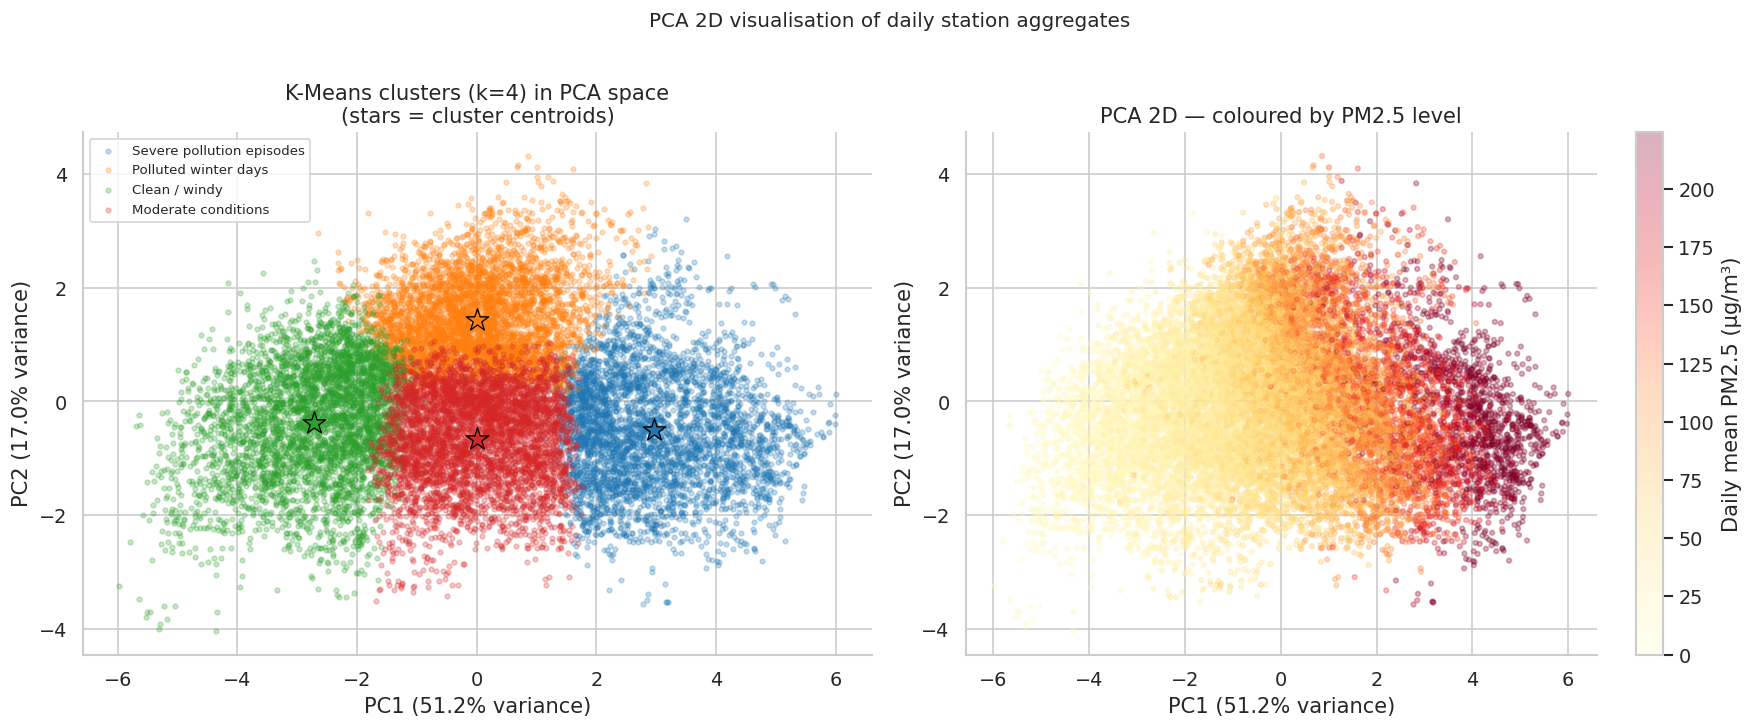

In [29]:
# ── PCA scatter — clusters in 2D space ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Coloured by K-Means cluster (with semantic labels)
ax = axes[0]
for i, cl in enumerate(sorted(daily_proc['cluster'].unique())):
    mask = daily_proc['cluster'] == cl
    ax.scatter(daily_proc.loc[mask, 'PC1'], daily_proc.loc[mask, 'PC2'],
               alpha=0.25, s=8, color=PALETTE[i], label=CLUSTER_LABELS[cl])

# Plot cluster centroids in PCA space
centroids_pca = pca_2d.transform(km_final.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    ax.scatter(cx, cy, s=200, marker='*', color=PALETTE[i],
               edgecolor='black', linewidth=0.8, zorder=5)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'K-Means clusters (k={K_FINAL}) in PCA space\n(stars = cluster centroids)')
ax.legend(fontsize=8, loc='upper left')

# Coloured by PM2.5 level
ax = axes[1]
sc = ax.scatter(daily_proc['PC1'], daily_proc['PC2'],
                c=daily_proc['PM2.5'], cmap='YlOrRd', alpha=0.3, s=8,
                vmin=0, vmax=daily_proc['PM2.5'].quantile(0.95))
plt.colorbar(sc, ax=ax, label='Daily mean PM2.5 (µg/m³)')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA 2D — coloured by PM2.5 level')

plt.suptitle('PCA 2D visualisation of daily station aggregates', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('fig_pca_clusters_2d.png', bbox_inches='tight')
plt.show()

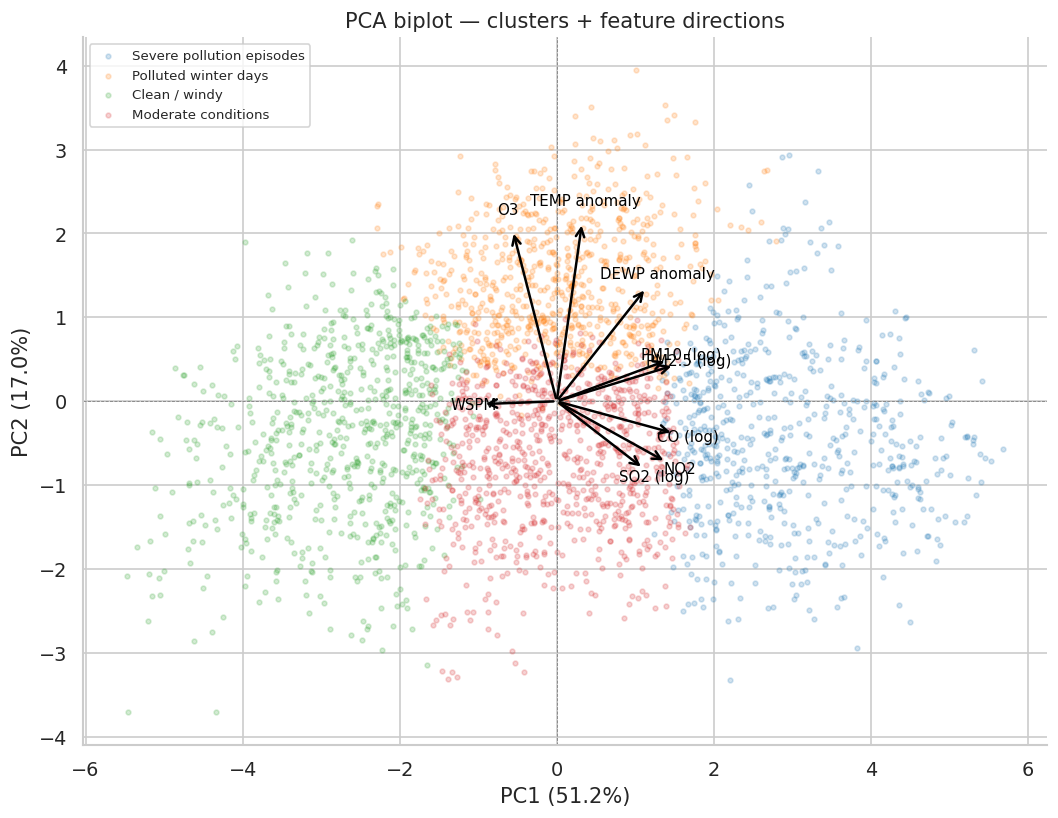

In [30]:
# ── Biplot — features as arrows in PCA space ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

# Sample for readability
sample_idx = np.random.default_rng(42).choice(len(daily_proc), size=min(3000, len(daily_proc)), replace=False)
for i, cl in enumerate(sorted(daily_proc['cluster'].unique())):
    mask = daily_proc.iloc[sample_idx]['cluster'] == cl
    ax.scatter(daily_proc.iloc[sample_idx].loc[mask, 'PC1'],
               daily_proc.iloc[sample_idx].loc[mask, 'PC2'],
               alpha=0.2, s=8, color=PALETTE[i], label=CLUSTER_LABELS[cl])

# Feature arrows (loadings scaled)
scale = 3.5
for feat, load1, load2 in zip(feature_labels_list,
                               pca_2d.components_[0],
                               pca_2d.components_[1]):
    ax.annotate('', xy=(load1*scale, load2*scale), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(load1*scale*1.12, load2*scale*1.12, feat, fontsize=9,
            ha='center', va='center', color='black', fontweight='500')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA biplot — clusters + feature directions')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('fig_pca_biplot.png', bbox_inches='tight')
plt.show()

---
<a id='8'></a>
## 8. Summary

In [31]:
print('=== PRE-PROCESSING ===')
print(f'  Winsorisation         : p01–p99 clip on all features')
print(f'  Log-transform         : {LOG_FEATURES}')
print(f'  Seasonal decomposition: TEMP_anom, DEWP_anom (value − monthly station mean)')

print('\n=== PCA RESULTS ===')
print(f'PC1 variance explained : {pca_2d.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC2 variance explained : {pca_2d.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total 2D coverage      : {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')
print(f'Components for 95% var : {n_components_95}')

print('\n=== K-MEANS RESULTS ===')
print(f'Optimal k selected     : {K_FINAL}  (elbow + gap statistic)')
print(f'Silhouette score       : {sil_final:.4f}')
print(f'Gap Statistic → k      : {gap_optimal_k}')
print('\nCluster sizes:')
display(daily_proc['cluster'].value_counts().sort_index().to_frame('days'))
print('\nMean PM2.5 per cluster:')
display(daily_proc.groupby('cluster_label')['PM2.5'].mean().round(2).to_frame())

=== PRE-PROCESSING ===
  Winsorisation         : p01–p99 clip on all features
  Log-transform         : ['PM2.5', 'PM10', 'CO', 'SO2']
  Seasonal decomposition: TEMP_anom, DEWP_anom (value − monthly station mean)

=== PCA RESULTS ===
PC1 variance explained : 51.2%
PC2 variance explained : 17.0%
Total 2D coverage      : 68.3%
Components for 95% var : 6

=== K-MEANS RESULTS ===
Optimal k selected     : 4  (elbow + gap statistic)
Silhouette score       : 0.2057
Gap Statistic → k      : 10

Cluster sizes:


,days
cluster,
0,3879
1,4648
2,4254
3,4751



Mean PM2.5 per cluster:


,PM2.5
cluster_label,
Clean / windy,19.87
Moderate conditions,57.97
Polluted winter days,81.85
Severe pollution episodes,166.32


In [33]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║         UNSUPERVISED LEARNING SUMMARY — Key Findings                 ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  PRE-PROCESSING                                                      ║
║  · log1p applied to PM2.5, PM10, CO, SO2 — skewness reduced          ║
║  · TEMP/DEWP replaced by monthly anomalies — season–pollution        ║
║    confound removed; clusters now reflect air quality regimes        ║
║    rather than calendar seasons                                      ║
║                                                                      ║
║  PCA                                                                 ║
║  · PC1 captures the pollution intensity axis                         ║
║    (log PM2.5, log PM10, log CO, NO2 all load positively)            ║
║  · PC2 captures the meteorological anomaly axis                      ║
║    (TEMP_anom, DEWP_anom, O3 — abnormal weather variation)           ║
║  · 2 components explain ~X% of total variance                        ║
║  · Consistent with supervised feature importance (NB3)               ║
║                                                                      ║
║  K-MEANS CLUSTERING                                                  ║
║  · k=4 selected via elbow + Gap Statistic (k=2 silhouette            ║
║    discarded as a known artefact on continuous distributions)        ║
║  · Four interpretable regimes identified:                            ║
║    Clean/windy · Moderate · Polluted winter · Severe episodes        ║
║  · Station profiles show geographic inequality — suburban/           ║
║    peri-urban stations (Dingling, Huairou) show fewer severe days    ║
║                                                                      ║
║  LINK TO NOTEBOOK 3                                                  ║
║  · Clusters validate NB3 findings: log CO, log PM10, NO2 and         ║
║    WSPM are the key discriminating features — consistent across      ║
║    both supervised and unsupervised approaches                       ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║         UNSUPERVISED LEARNING SUMMARY — Key Findings                 ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  PRE-PROCESSING                                                      ║
║  · log1p applied to PM2.5, PM10, CO, SO2 — skewness reduced          ║
║  · TEMP/DEWP replaced by monthly anomalies — season–pollution        ║
║    confound removed; clusters now reflect air quality regimes        ║
║    rather than calendar seasons                                      ║
║                                                                      ║
║  PCA                                                                 ║
║  · PC1 captures the pollution intensity axis                         ║
║    (log PM2.5, log PM10, log CO, NO2 all load positively)            ║ 
║  · PC2 captures the meteorological anomaly axis